# MawinguSentry: Exploratory Data Analysis

Sanity-checking the feature engineering pipeline (`app/features.py`) against
`data/sample_1k.jsonl` before training a model on it. The goal here is to
confirm the 24 engineered features actually separate the five MITRE-mapped
attack scenarios from benign traffic -- not to draw final conclusions about
model performance, which needs real train/test evaluation, not EDA plots.

In [ ]:
import json
import sys

sys.path.insert(0, "..")  # so `app` is importable when run from notebooks/

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from app.features import CloudEventFeatureEngineer

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

events = [json.loads(line) for line in open("../data/sample_1k.jsonl")]
engineer = CloudEventFeatureEngineer()
features = engineer.fit_transform(events)
features["label"] = [e["label"] for e in events]
features["scenario_id"] = [e.get("scenario_id") or "benign" for e in events]

features.shape

2026-09-03 09:35:32,032 - app.features - INFO - Fitted on 1000 events, baselines learned for 4 principals


2026-09-03 09:35:32,034 - app.features - INFO - Feature columns (25): ['hour_of_day', 'is_off_hours', 'seconds_since_last_event', 'events_in_last_5min', 'is_new_ip_for_principal', 'is_new_region_for_principal', 'is_new_event_type_for_principal', 'is_sensitive_call', 'is_recon_call', 'rapid_region_change', 'rapid_ip_change', 'event_is_AssumeRole', 'event_is_AttachUserPolicy', 'event_is_ConsoleLogin', 'event_is_CreateAccessKey', 'event_is_DescribeInstances', 'event_is_DescribeLogGroups', 'event_is_DescribeSecurityGroups', 'event_is_GetCallerIdentity', 'event_is_GetObject', 'event_is_ListBuckets', 'event_is_ListRoles', 'event_is_PutBucketAcl', 'event_is_PutBucketPolicy', 'event_is_PutMetricData']


(1000, 27)

## Dataset overview

In [2]:
print(features["label"].value_counts())
print()
print(features["scenario_id"].value_counts())

label
benign       844
malicious    156
Name: count, dtype: int64

scenario_id
benign                     844
recon_burst                 94
public_bucket_exposure      19
unusual_geo_login           16
privilege_escalation        15
cred_exfil_key_creation     12
Name: count, dtype: int64


156 malicious events out of 1,000 (~15.6%), spread across the five MITRE
scenarios -- `recon_burst` dominates the malicious count because each
instance generates 6 events (the reconnaissance calls), while the other four
scenarios generate 1 event each. Worth remembering when interpreting raw
counts: scenario *instances*, not scenario *event counts*, are what's
balanced by the generator's attack_ratio.

## Do the key features separate attack scenarios from benign traffic?

In [3]:
key_features = [
    "is_sensitive_call", "is_recon_call", "rapid_ip_change",
    "is_new_region_for_principal", "events_in_last_5min", "is_off_hours",
]
summary = features.groupby("scenario_id")[key_features].mean().round(3)
summary

,is_sensitive_call,is_recon_call,rapid_ip_change,is_new_region_for_principal,events_in_last_5min,is_off_hours
scenario_id,,,,,,
benign,0.0,0.501,0.0,0.0,0.033,0.141
cred_exfil_key_creation,1.0,0.000,0.0,0.0,0.000,0.417
privilege_escalation,1.0,0.000,0.0,0.0,0.000,0.067
public_bucket_exposure,1.0,0.000,0.0,0.0,0.053,0.000
recon_burst,0.0,1.000,0.0,0.0,2.457,0.064
unusual_geo_login,0.0,0.000,1.0,0.0,1.000,0.062


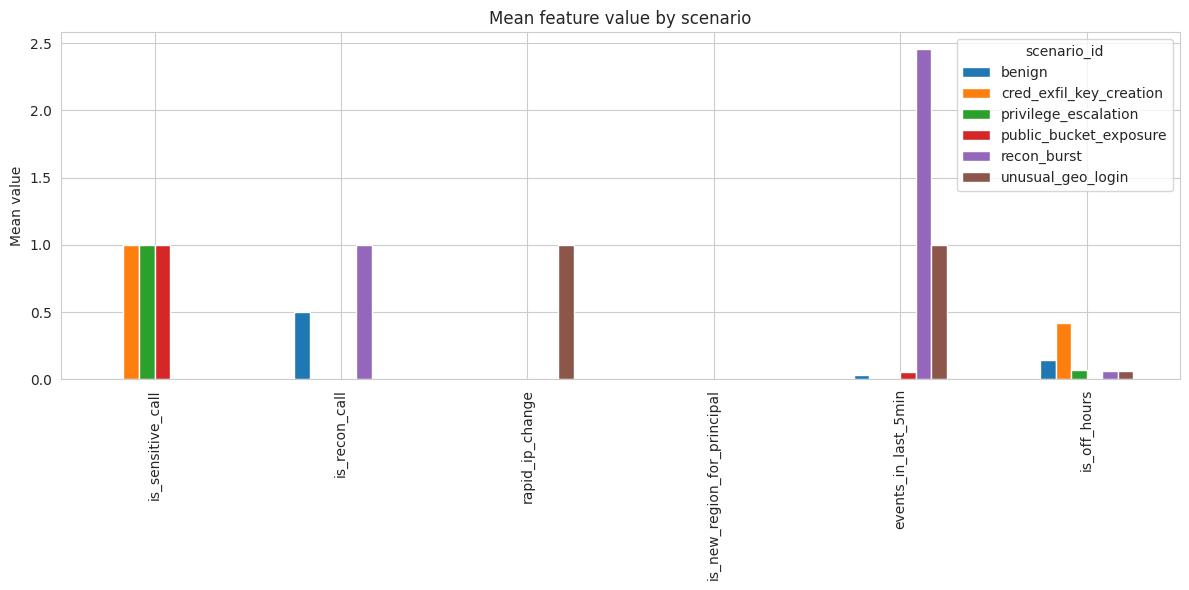

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
summary.T.plot(kind="bar", ax=ax)
ax.set_title("Mean feature value by scenario")
ax.set_ylabel("Mean value")
plt.tight_layout()
plt.show()

**Explaining Key:**

- `is_sensitive_call` is a perfect 1.0 for `privilege_escalation`,
  `public_bucket_exposure`, and `cred_exfil_key_creation` -- exactly the
  three scenarios that involve a sensitive IAM/S3 call. Clean signal.
- `rapid_ip_change` is 1.0 only for `unusual_geo_login`, as designed --
  this is the feature standing in for "impossible travel" detection.
- `is_recon_call` is 1.0 for `recon_burst`, but notably **not 0 for
  benign** (see the box plot below) -- individual recon-looking calls
  (`ListBuckets`, `DescribeInstances`) are completely normal on their own.
  It's the *rate* of these calls, not their presence, that's the real
  signal -- which is exactly what `events_in_last_5min` captures.
- `is_new_region_for_principal` is **flat 0 across every scenario**,
  including the ones you'd expect it to fire for. None of the five current
  attack scenarios actually change a principal's AWS region -- only IP
  address. This feature is dead weight in the current model and either
  needs a scenario that exercises it (e.g. a role assumed cross-region)
  or should be dropped before training.

## Burst detection: benign vs malicious

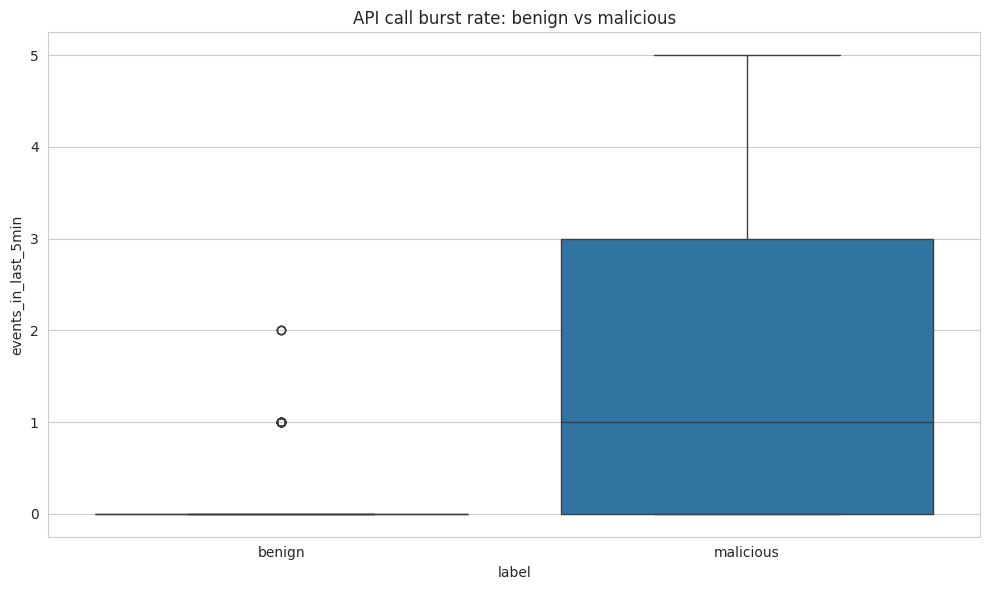

In [5]:
fig, ax = plt.subplots()
sns.boxplot(data=features, x="label", y="events_in_last_5min", ax=ax)
ax.set_title("API call burst rate: benign vs malicious")
plt.tight_layout()
plt.show()

Clean separation -- benign traffic almost never exceeds 1-2 calls in a
5-minute window per principal; malicious events (driven by `recon_burst`)
regularly hit 3-5. This is likely to be one of the strongest individual
features for the model.

## Time-of-day patterns

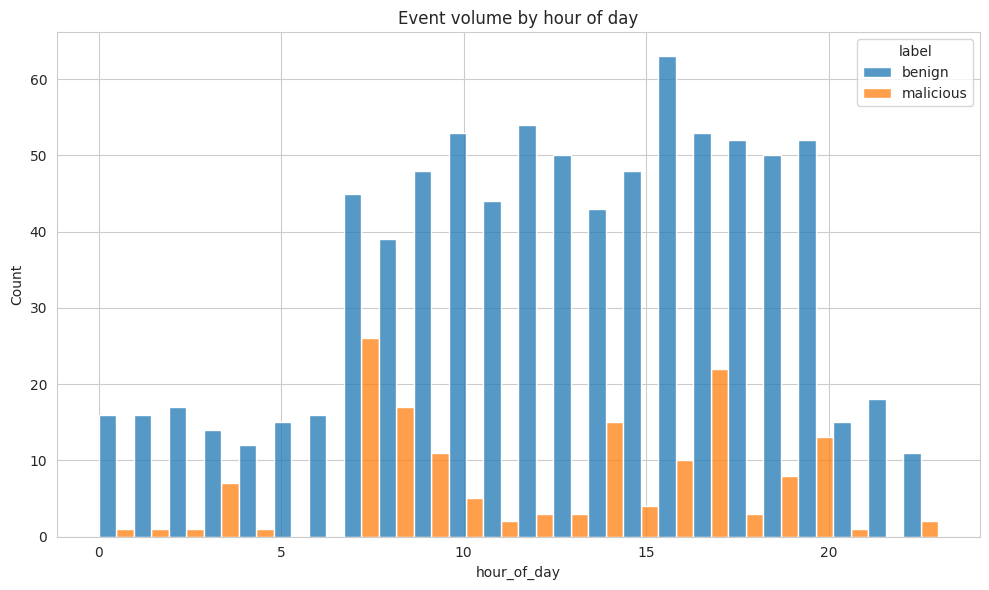

In [6]:
fig, ax = plt.subplots()
sns.histplot(data=features, x="hour_of_day", hue="label", multiple="dodge", bins=24, ax=ax)
ax.set_title("Event volume by hour of day")
plt.tight_layout()
plt.show()

Less useful than expected on its own -- both benign and malicious traffic
roughly track the same business-hours-weighted distribution (a side effect
of `_random_base_time()` biasing all events, attack or not, toward business
hours). `is_off_hours` may still combine usefully with other features, but
it isn't a strong standalone signal in this dataset. Worth revisiting if a
future scenario specifically models off-hours attacker behavior.

## Feature correlation

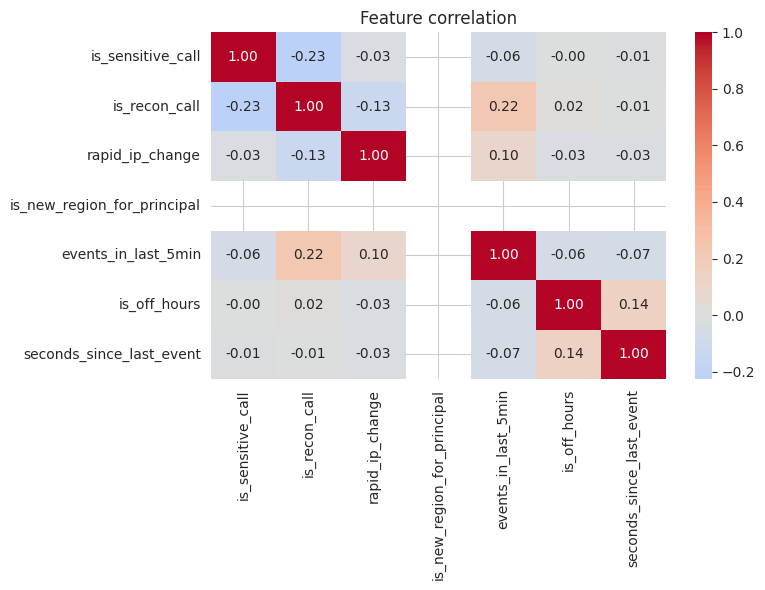

In [7]:
corr_features = key_features + ["seconds_since_last_event"]
corr = features[corr_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax, fmt=".2f")
ax.set_title("Feature correlation")
plt.tight_layout()
plt.show()

No pair is strongly correlated (all under |0.25|), so there's no obvious
redundancy to prune before training -- each feature is contributing
distinct information. `is_new_region_for_principal` shows no correlation
values at all since it's constant (zero variance).

## Takeaways for Week 2 model training

1. **`is_sensitive_call`, `rapid_ip_change`, and `events_in_last_5min`** are
   the strongest individual signals found so far -- each cleanly isolates
   at least one attack scenario.
2. **`is_recon_call` alone is not enough** -- it needs to be combined with
   burst rate, since single recon-style calls are common in benign use.
3. **`is_new_region_for_principal` is currently dead weight.** Before
   training, either drop it or add a scenario that actually exercises it
   (e.g. a role used from an unexpected AWS region, not just an unexpected
   IP). Leaving a zero-variance feature in a small feature set isn't
   harmful to most models, but it's worth being deliberate about rather
   than silently carrying it forward.
4. **`hour_of_day` / `is_off_hours` are weak on their own** in this
   synthetic dataset, since attack timing wasn't deliberately biased away
   from benign timing. A more adversarial dataset design might inject
   more attacks during off-hours, matching real-world attacker behavior
   more closely.
5. No problematic feature correlation -- safe to bring the full feature
   set into model training without a separate pruning step.